## Iteration 1: PCA

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


df = pd.read_csv("/content/drive/MyDrive/DelayData.csv")

df.dropna(inplace=True)

print("DataFrame columns:")
print(df.columns)


DataFrame columns:
Index(['depdelay', 'arrdelay', 'scheduleddepartdatetime', 'origin', 'dest',
       'uniquecarrier', 'marketshareorigin', 'marketsharedest', 'hhiorigin',
       'hhidest', 'nonhubairportorigin', 'smallhubairportorigin',
       'mediumhubairportorigin', 'largehubairportorigin', 'nonhubairportdest',
       'smallhubairportdest', 'mediumhubairportdest', 'largehubairportdest',
       'nonhubairlineorigin', 'smallhubairlineorigin',
       'mediumhubairlineorigin', 'largehubairlineorigin', 'nonhubairlinedest',
       'smallhubairlinedest', 'mediumhubairlinedest', 'largehubairlinedest',
       'year', 'month', 'dayofmonth', 'dayofweek', 'scheduledhour',
       'originairportid', 'destairportid', 'tailnum', 'capacity', 'loadfactor',
       'numflights', 'origincityname', 'originstate', 'distance',
       'monopolyroute', 'temperature', 'temp_ninfty_n10', 'temp_n10_0',
       'temp_0_10', 'temp_10_20', 'temp_20_30', 'temp_30_40', 'temp_40_infty',
       'windspeed', 'windspeed

In [ ]:
#define feature groups
temp_bins = [
    'temp_ninfty_n10', 'temp_n10_0', 'temp_0_10',
    'temp_10_20', 'temp_20_30', 'temp_30_40', 'temp_40_infty'
]
weather_dummies = ['raindummy', 'raintracedummy', 'snowdummy', 'snowtracedummy', 'windgustdummy']
continuous_weather = ['temperature', 'windspeed', 'windspeedsquare', 'windgustspeed']

#combine all into one weather category for PCA
weather_features = temp_bins + weather_dummies + continuous_weather



In [ ]:
#scale data
scaler = StandardScaler()
weather_scaled = scaler.fit_transform(df[weather_features])



In [ ]:
#run PCA
pca = PCA()
weather_pca = pca.fit_transform(weather_scaled)



In [ ]:
#analyze variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Variance explained by first 3 components: {cumulative_variance[2]:.2%}")



Variance explained by first 3 components: 43.04%


In [ ]:
#interpret component one
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(weather_features))],
    index=weather_features
)

print("\nTop influences for Principal Component 1 (Primary Weather State):")
print(loadings['PC1'].sort_values(ascending=False).head(5))




Top influences for Principal Component 1 (Primary Weather State):
windspeedsquare    0.525195
windspeed          0.513549
windgustspeed      0.483234
windgustdummy      0.455927
snowtracedummy     0.056292
Name: PC1, dtype: float64


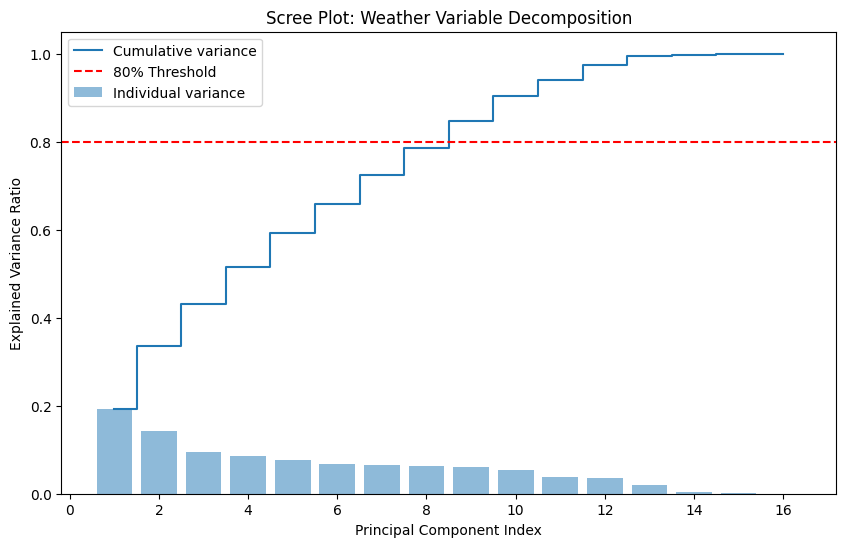

In [ ]:
#make scree plot
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5, align='center', label='Individual variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Cumulative variance')
plt.axhline(y=0.8, color='r', linestyle='--', label='80% Threshold')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Component Index')
plt.legend(loc='best')
plt.title('Scree Plot: Weather Variable Decomposition')
plt.show()



In [ ]:
df['Weather_State_1'] = weather_pca[:, 0]
df['Weather_State_2'] = weather_pca[:, 1]
df['Weather_State_3'] = weather_pca[:, 2]

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

model_df = df.dropna(subset=['year', 'arrdelay', 'Weather_State_1', 'Weather_State_2', 'Weather_State_3']).copy()

X = model_df[['Weather_State_1', 'Weather_State_2', 'Weather_State_3']]
y = model_df['arrdelay']

train_mask = model_df['year'] <= 2014
test_mask = model_df['year'] > 2014

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

regressor = LinearRegression()
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Regression Model Results (Target: Arrival Delay) ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.4f}")

coefficients = pd.DataFrame(regressor.coef_, X.columns, columns=['Coefficient'])
print("\nModel Coefficients:")
print(coefficients)

--- Regression Model Results (Target: Arrival Delay) ---
Mean Squared Error (MSE): 1748.75
R-squared (R2): 0.0018

Model Coefficients:
                 Coefficient
Weather_State_1     1.445941
Weather_State_2    -0.251461
Weather_State_3    -1.148025


## Iteration 2: Random Forest Regression

Reading in data...
Cleaning data...
Splitting data...
Training Random Forest Model (this may take a minute or two)...
Evaluating Model...

--- Random Forest Regression Results (Target: Arrival Delay) ---
Mean Squared Error (MSE): 1720.26
R-squared (R2): 0.0180


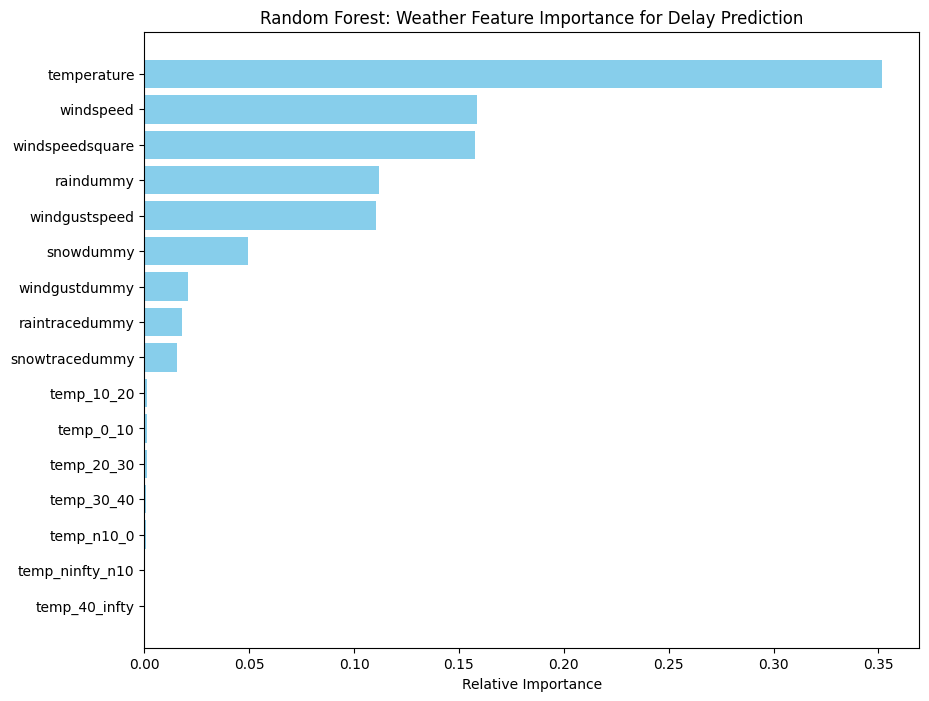

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

#read in Data
df = pd.read_csv("/content/drive/MyDrive/DelayData.csv")

#define feature groups
temp_bins = [
    'temp_ninfty_n10', 'temp_n10_0', 'temp_0_10',
    'temp_10_20', 'temp_20_30', 'temp_30_40', 'temp_40_infty'
]
weather_dummies = ['raindummy', 'raintracedummy', 'snowdummy', 'snowtracedummy', 'windgustdummy']
continuous_weather = ['temperature', 'windspeed', 'windspeedsquare', 'windgustspeed']

#combine into one list
weather_features = temp_bins + weather_dummies + continuous_weather

#drop rows with missing data
model_df = df.dropna(subset=['year', 'arrdelay'] + weather_features).copy()

#define x and y
X = model_df[weather_features]
y = model_df['arrdelay']

#split data
train_mask = model_df['year'] <= 2014
test_mask = model_df['year'] > 2014

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

#train random forest
#max_depth is set to 15 to prevent overfitting and speed up training on large data
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

#make predictions and find performance metrics
print("Evaluating Model...")
y_pred = rf_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Random Forest Regression Results (Target: Arrival Delay) ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.4f}")

#create feature importance graph
importances = rf_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Relative Importance')
plt.title('Random Forest: Weather Feature Importance for Delay Prediction')
plt.show()

## Iteration 3: Random Forest Classification

Reading in data...
Cleaning data and creating classifications...
Splitting data chronologically...
Training Random Forest Classifier (this may take a minute or two)...
Evaluating Model...

--- Random Forest Classification Results ---
Overall Accuracy: 43.32%

Classification Report:
                        precision    recall  f1-score   support

                 Early       0.67      0.57      0.62    201427
           Major Delay       0.13      0.26      0.17     24131
        Moderate Delay       0.12      0.15      0.13     32412
On-time or Small Delay       0.20      0.19      0.19     59945

              accuracy                           0.43    317915
             macro avg       0.28      0.29      0.28    317915
          weighted avg       0.49      0.43      0.46    317915



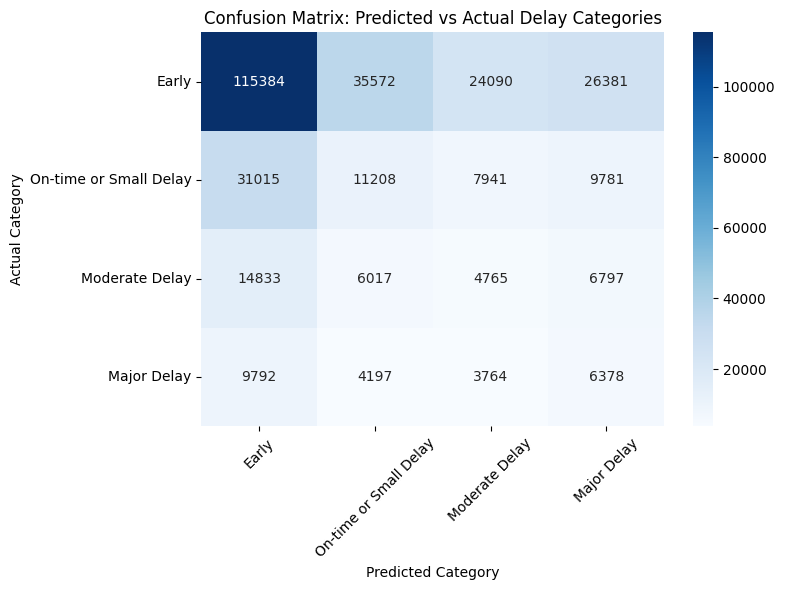

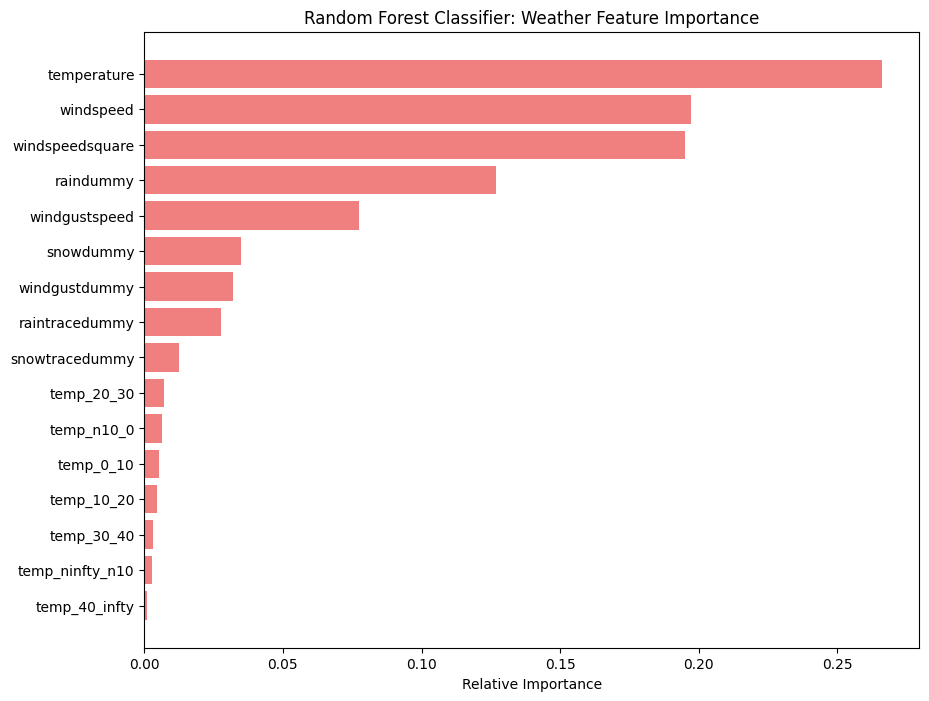

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

#read in Data
df = pd.read_csv("/content/drive/MyDrive/DelayData.csv")

#define feature groups
temp_bins = [
    'temp_ninfty_n10', 'temp_n10_0', 'temp_0_10',
    'temp_10_20', 'temp_20_30', 'temp_30_40', 'temp_40_infty'
]
weather_dummies = ['raindummy', 'raintracedummy', 'snowdummy', 'snowtracedummy', 'windgustdummy']
continuous_weather = ['temperature', 'windspeed', 'windspeedsquare', 'windgustspeed']

#combine into one list
weather_features = temp_bins + weather_dummies + continuous_weather

#drop rows with missing data
model_df = df.dropna(subset=['year', 'arrdelay'] + weather_features).copy()

#create delay bins
bins = [-np.inf, 0, 15, 45, np.inf]
labels = ['Early', 'On-time or Small Delay', 'Moderate Delay', 'Major Delay']
model_df['delay_class'] = pd.cut(model_df['arrdelay'], bins=bins, labels=labels, right=False)

#define x and y
X = model_df[weather_features]
y = model_df['delay_class']

#split data
train_mask = model_df['year'] <= 2014
test_mask = model_df['year'] > 2014

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]


#train random forest
#max_depth is set to 15 to prevent overfitting and speed up training on large data
#class_weight='balanced' to handle skewed classes
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1)
rf_classifier.fit(X_train, y_train)

#make predictions and find performance metrics
print("Evaluating Model...")
y_pred = rf_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n--- Random Forest Classification Results ---")
print(f"Overall Accuracy: {accuracy:.2%}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

#create confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: Predicted vs Actual Delay Categories')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#create feature importance graph
importances = rf_classifier.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='lightcoral')
plt.xlabel('Relative Importance')
plt.title('Random Forest Classifier: Weather Feature Importance')
plt.show()

## Iteration 4: Random Forest Classification w/ Geographic and Logistical Features

Reading in data...
Cleaning data and creating classifications...
Encoding geographic and categorical features...
Splitting data chronologically...
Training Random Forest Classifier (this may take a few minutes with the new features)...
Evaluating Model...

--- Random Forest Classification Results ---
Overall Accuracy: 41.44%

Classification Report:
                        precision    recall  f1-score   support

                 Early       0.72      0.52      0.61    201427
           Major Delay       0.13      0.46      0.21     24131
        Moderate Delay       0.14      0.24      0.18     32412
On-time or Small Delay       0.22      0.12      0.16     59945

              accuracy                           0.41    317915
             macro avg       0.30      0.34      0.29    317915
          weighted avg       0.52      0.41      0.45    317915



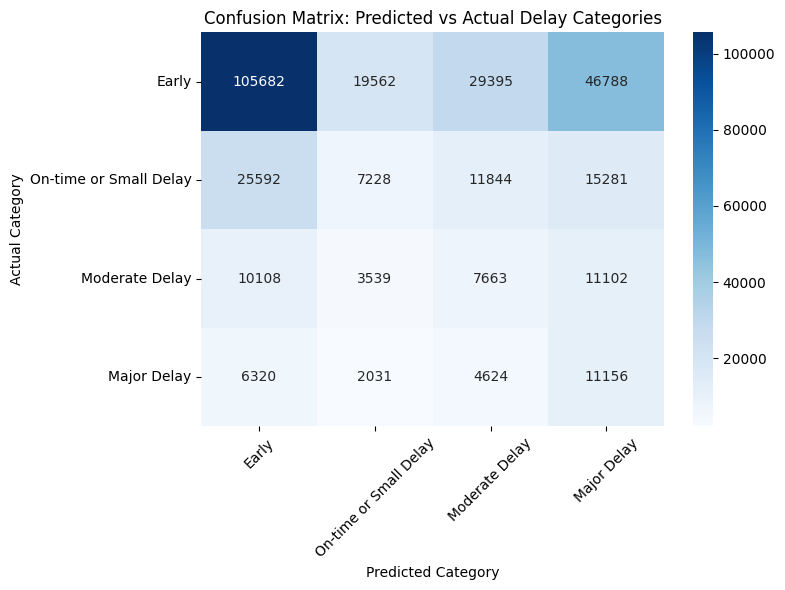

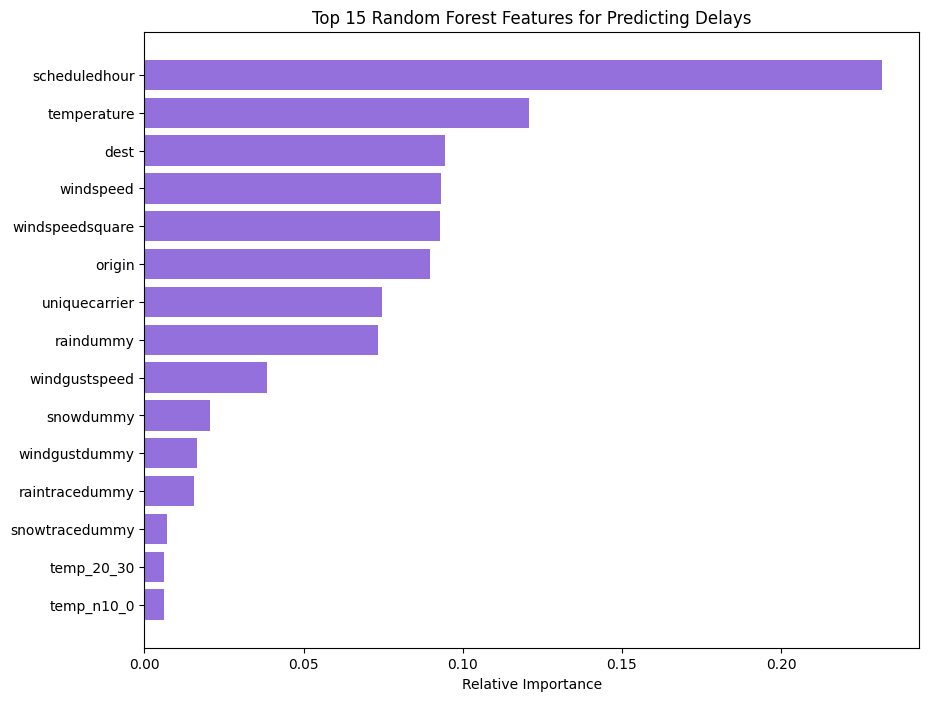

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import OrdinalEncoder

#read in data
df = pd.read_csv("/content/drive/MyDrive/DelayData.csv")

#define feature groups
temp_bins = [
    'temp_ninfty_n10', 'temp_n10_0', 'temp_0_10',
    'temp_10_20', 'temp_20_30', 'temp_30_40', 'temp_40_infty'
]
weather_dummies = ['raindummy', 'raintracedummy', 'snowdummy', 'snowtracedummy', 'windgustdummy']
continuous_weather = ['temperature', 'windspeed', 'windspeedsquare', 'windgustspeed']

#add geographic and logistical variables
geo_log_features = ['origin', 'dest', 'uniquecarrier', 'scheduledhour']

#combine into one list
all_features = temp_bins + weather_dummies + continuous_weather + geo_log_features

#drop rows with missing data
model_df = df.dropna(subset=['year', 'arrdelay'] + all_features).copy()

#use ordinal encoder to change alphabetical variables to numerical
print("Encoding geographic and categorical features...")
encoder = OrdinalEncoder()
categorical_cols = ['origin', 'dest', 'uniquecarrier']
model_df[categorical_cols] = encoder.fit_transform(model_df[categorical_cols])

#create delay bbins
bins = [-np.inf, 0, 15, 45, np.inf]
labels = ['Early', 'On-time or Small Delay', 'Moderate Delay', 'Major Delay']
model_df['delay_class'] = pd.cut(model_df['arrdelay'], bins=bins, labels=labels, right=False)

#define x and y
X = model_df[all_features]
y = model_df['delay_class']

#split data
train_mask = model_df['year'] <= 2014
test_mask = model_df['year'] > 2014

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

#train random forest
print("Training Random Forest Classifier (this may take a few minutes with the new features)...")
rf_classifier = RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced', random_state=42, n_jobs=-1)
rf_classifier.fit(X_train, y_train)

#make predictions and find performance metrics
print("Evaluating Model...")
y_pred = rf_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n--- Random Forest Classification Results ---")
print(f"Overall Accuracy: {accuracy:.2%}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

#create confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: Predicted vs Actual Delay Categories')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#create feature importance graph
importances = rf_classifier.feature_importances_
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(15) # Show top 15
importance_df = importance_df.sort_values(by='Importance', ascending=True) # Reverse for barh plot

plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='mediumpurple')
plt.xlabel('Relative Importance')
plt.title('Top 15 Random Forest Features for Predicting Delays')
plt.show()

## Bar Chart of Delay Distribution

/tmp/ipykernel_10919/365563519.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


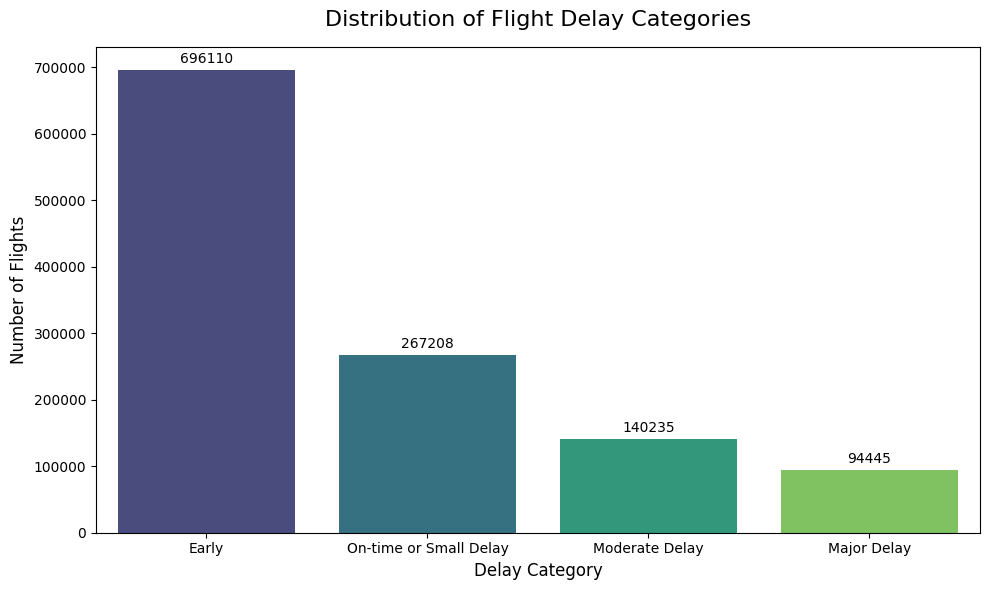

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10, 6))

#create the bar chart using seaborn's countplot
ax = sns.countplot(
    data=model_df,
    x='delay_class',
    order=labels,
    palette='viridis' # You can change the color palette (e.g., 'Blues', 'Set2', 'magma')
)

plt.title('Distribution of Flight Delay Categories', fontsize=16, pad=15)
plt.xlabel('Delay Category', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 8),
                textcoords = 'offset points',
                fontsize=10)

plt.tight_layout()
plt.show()